# Jaguar Re-ID — ResNet-34 Improved v6

**Architecture** : ResNet-34 (BatchNorm + ReLU, Dropout 0.4, AdamW)  
**Changement vs 06_2** : Label smoothing 0.1 (« noisy targets » du cours)

## 1. Setup & data loading

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.data import load_data, load_test_pairs, get_augmentation

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1776166385.410198   27976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776166386.011313   27976 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776166387.755278   27976 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1776166389.681294   27976 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [2]:
PROJECT_ROOT   = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR       = os.path.join(PROJECT_ROOT, 'data')
CLEANED_DIR    = os.path.join(DATA_DIR, 'cleaned')
OUTPUT_DIR     = os.path.join(PROJECT_ROOT, 'outputs')
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, 'submissions')
LOG_DIR        = os.path.join(PROJECT_ROOT, 'tensorboards')

IMG_SIZE = 224
NUM_CLASSES = 31
BATCH_SIZE = 64
SEED = 42

MODEL_NAME      = 'resnet34_improved_v6'
AUGMENTATION    = 'none'
LABEL_SMOOTHING = 0.1  # "noisy targets" (cours)

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
X_test, test_filenames = load_data('test')
test_pairs_df = load_test_pairs()

# One-hot encoding for label smoothing
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Labels: int {y_train.shape} -> one-hot {y_train_oh.shape}")

Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3) | Test: (371, 224, 224, 3)
Labels: int (1516,) -> one-hot (1516, 31)


## 2. ResNet-34 architecture

Identique à 06_2 : Conv → BatchNorm → ReLU, Dropout 0.4, shortcuts avec Conv1x1+BN.

In [4]:
def residual_block(x, filters, stride=1):
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=(stride, stride), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, (3, 3), strides=(1, 1), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=(stride, stride), padding='valid', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x


def create_resnet34(input_shape, num_classes, augmentation='none'):
    inputs = keras.Input(input_shape)

    aug = get_augmentation(augmentation)
    x = aug(inputs) if aug is not None else inputs

    # Initial conv + pool
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Layer 1: 3 blocks, 64 filters
    for _ in range(3):
        x = residual_block(x, 64)

    # Layer 2: 4 blocks, 128 filters (first with stride 2)
    x = residual_block(x, 128, stride=2)
    for _ in range(3):
        x = residual_block(x, 128)

    # Layer 3: 6 blocks, 256 filters (first with stride 2)
    x = residual_block(x, 256, stride=2)
    for _ in range(5):
        x = residual_block(x, 256)

    # Layer 4: 3 blocks, 512 filters (first with stride 2)
    x = residual_block(x, 512, stride=2)
    for _ in range(2):
        x = residual_block(x, 512)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs)


def build_model():
    return create_resnet34((IMG_SIZE, IMG_SIZE, 3), NUM_CLASSES, augmentation=AUGMENTATION)

model = build_model()
model.summary()

W0000 00:00:1776166393.628827   27976 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1776166393.819858   27976 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13209 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,408 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,864 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 56, 56,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,864 │ re_lu_3[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_4[0][0]  

 Total params: 21,317,599 (81.32 MB)

 Trainable params: 21,300,575 (81.26 MB)

 Non-trainable params: 17,024 (66.50 KB)

## 3. Hyperparameter sweep

Config identique à 06_2 sauf la loss : `CategoricalCrossentropy(label_smoothing=0.1)`.  
Le label smoothing remplace les labels one-hot durs par des distributions adoucies (0.9 / 0.003).

In [5]:
WEIGHT_DECAY = 5e-4

def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.AdamW(learning_rate=lr, weight_decay=WEIGHT_DECAY),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        X_train, y_train_oh,
        validation_data=(X_val, y_val_oh),
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=20, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(X_val, y_val_oh, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [6]:
lr_candidates = [1e-3, 5e-4, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (resnet34_improved_v6) ===


I0000 00:00:1776166399.698220   29160 service.cc:153] XLA service 0x7fad900860b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776166399.698263   29160 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070 Ti, Compute Capability 12.0a (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776166399.877153   29160 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776166401.246669   29160 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776166401.469701   29160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25469__.242
I0000 00:00:1776166411.236863   29160 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1776166414.361019   29161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_25469__

  lr_0.001: val_acc=0.8918 (best epoch=99)


I0000 00:00:1776166616.537525   29158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108518__.242
I0000 00:00:1776166623.904111   29161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_108518__.242


  lr_0.0005: val_acc=0.8786 (best epoch=56)


I0000 00:00:1776166776.528572   29159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176325__.242
I0000 00:00:1776166781.390077   29159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176325__.242


  lr_0.0001: val_acc=0.7652 (best epoch=47)


In [7]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} → val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.891821,99
1,lr_0.0005,0.878628,56
2,lr_0.0001,0.765172,47



Best: lr_0.001 → val_acc=0.8918


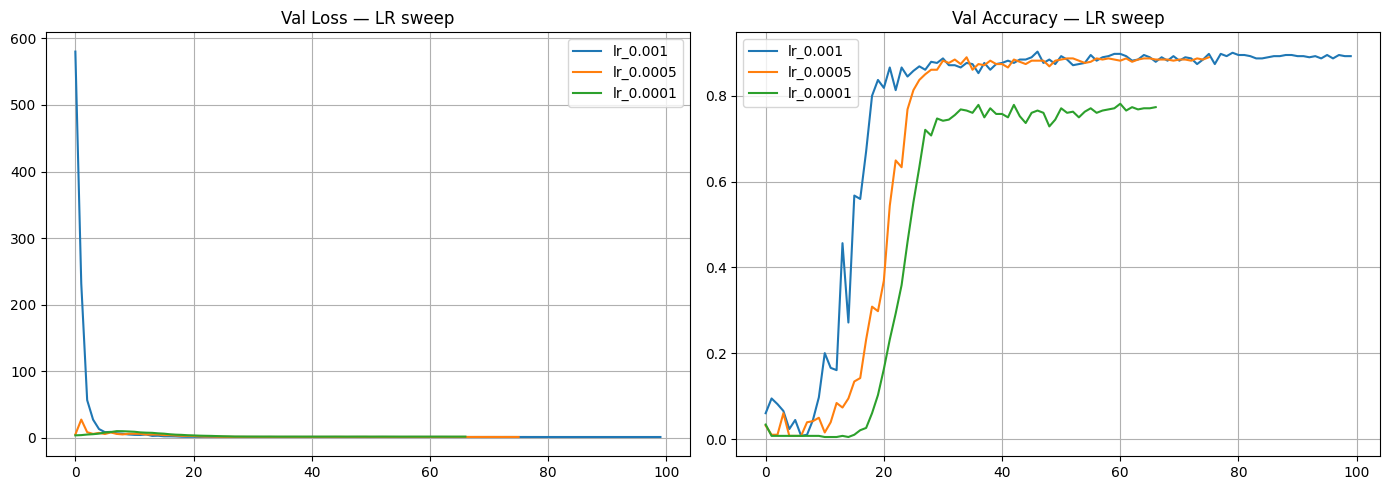

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss — LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy — LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [9]:
model = build_model()
model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-7, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1776166919.141520   29157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_238138__.242


23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.0952 - loss: 4.3395

I0000 00:00:1776166926.600554   29160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_238138__.242


24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step - accuracy: 0.1273 - loss: 3.8311 - val_accuracy: 0.0185 - val_loss: 426.6808 - learning_rate: 0.0010
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.2520 - loss: 2.9416 - val_accuracy: 0.0950 - val_loss: 86.3834 - learning_rate: 0.0010
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.3727 - loss: 2.5365 - val_accuracy: 0.0554 - val_loss: 16.1206 - learning_rate: 0.0010
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.4881 - loss: 2.1989 - val_accuracy: 0.0686 - val_loss: 10.3621 - learning_rate: 0.0010
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.5818 - loss: 1.9332 - val_accuracy: 0.0739 - val_loss: 9.7769 - learning_rate: 0.0010
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - accuracy: 0.6774 - loss: 1.7132 - val_accuracy: 0.0580 - val_loss: 6.3872 - learning_rate: 0.0010
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.7111 - loss: 1.6152 -

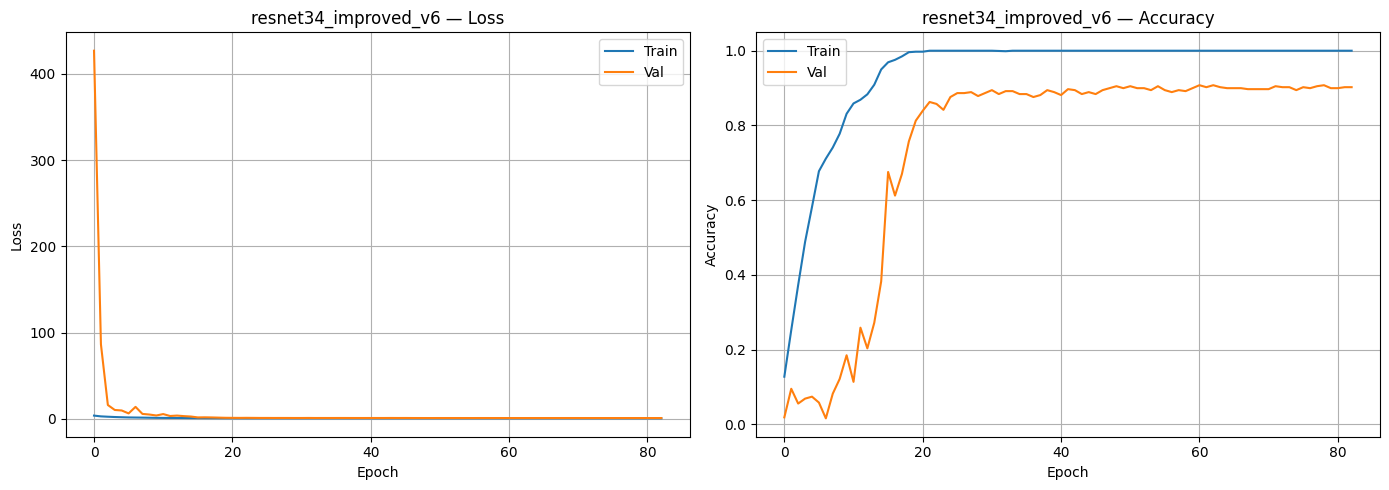

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} — Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} — Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [11]:
train_loss, train_acc = model.evaluate(X_train, y_train_oh, verbose=0)
val_loss, val_acc     = model.evaluate(X_val, y_val_oh, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}, label_smoothing={LABEL_SMOOTHING}):")
print(f"  Train — Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   — Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

resnet34_improved_v6 (best LR=0.001, label_smoothing=0.1):
  Train — Loss: 0.6566, Acc: 1.0000
  Val   — Loss: 1.0086, Acc: 0.9077


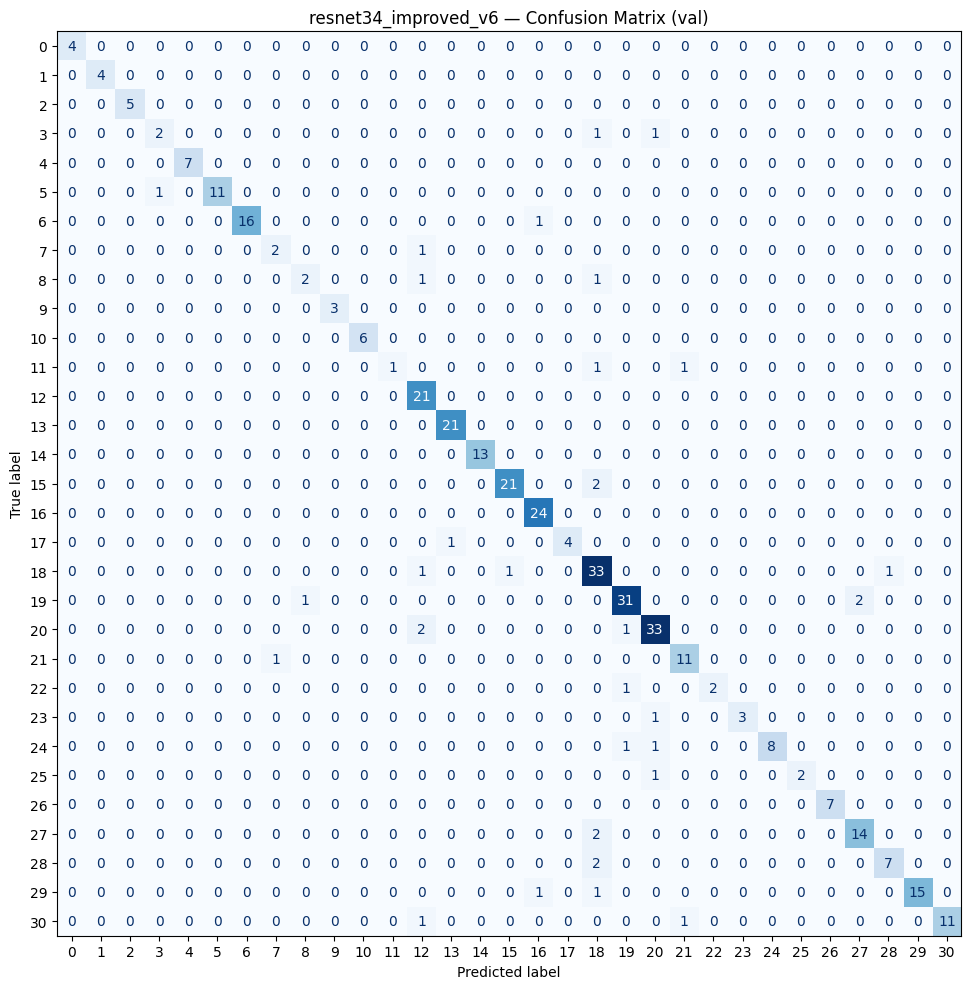

In [12]:
y_val_pred = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} — Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [13]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
y_all_oh = tf.keras.utils.to_categorical(y_all, NUM_CLASSES)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.AdamW(learning_rate=BEST_LR, weight_decay=WEIGHT_DECAY),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    X_all, y_all_oh,
    epochs=BEST_EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(X_all, y_all_oh, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 99 epochs
Epoch 1/99


I0000 00:00:1776167174.472065   29159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2368098__.242


29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1086 - loss: 4.1555

I0000 00:00:1776167182.641006   29158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2368098__.242
I0000 00:00:1776167184.473712   58521 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_6', 16 bytes spill stores, 16 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 24s 389ms/step - accuracy: 0.1662 - loss: 3.6456
Epoch 2/99
30/30 ━━━━━━━━━━━━━━━━━━━━ -1s -26579us/step - accuracy: 0.3325 - loss: 2.7591
Epoch 3/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.4401 - loss: 2.4572
Epoch 4/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5367 - loss: 2.1055
Epoch 5/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6148 - loss: 1.8772
Epoch 6/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.6813 - loss: 1.7020
Epoch 7/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.7398 - loss: 1.5063
Epoch 8/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.7858 - loss: 1.3763
Epoch 9/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8179 - loss: 1.2919
Epoch 10/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8517 - loss: 1.1869
Epoch 11/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8834 - loss: 1.1185
Epoch 12/99
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8

I0000 00:00:1776167395.665452   63576 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 16 bytes spill stores, 16 bytes spill loads



Final train acc: 1.0000


In [14]:
embedding_model = keras.Model(
    inputs=final_model.input,
    outputs=final_model.layers[-2].output,
    name=f'{MODEL_NAME}_embedding'
)

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

similarities = np.clip(
    np.sum(test_embeddings_norm[query_idx] * test_embeddings_norm[gallery_idx], axis=1),
    0, 1
)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step
Embedding shape: (371, 512)
Saved: /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v6.csv


,row_id,similarity
0,0,0.894549
1,1,0.603017
2,2,0.741909
3,3,0.784940
4,4,0.888668


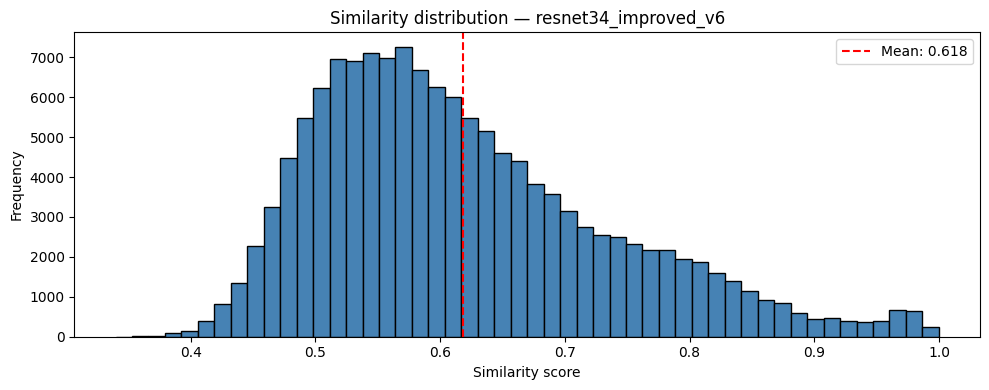

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution — {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [16]:
print(f"""
ResNet-34 improved v6 (label smoothing = {LABEL_SMOOTHING}):
  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}
  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}
  Best LR: {BEST_LR}, Best Epoch: {BEST_EPOCH}
  Embedding dim: {test_embeddings.shape[1]}

vs 06_2 (no label smoothing):
  Val Acc: 88.65%, Kaggle: 0.566 / 0.542

Submission -> {submission_path}
""")


ResNet-34 improved v6 (label smoothing = 0.1):
  Train - Loss: 0.6566, Acc: 1.0000
  Val   - Loss: 1.0086, Acc: 0.9077
  Best LR: 0.001, Best Epoch: 99
  Embedding dim: 512

vs 06_2 (no label smoothing):
  Val Acc: 88.65%, Kaggle: 0.566 / 0.542

Submission -> /home/franck/kaggle_jaguar_classification/submissions/submission_resnet34_improved_v6.csv



## 7. Observations & Verdict

### Results

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | TODO  | TODO |
| Loss     | TODO  | TODO |
| Overfitting ? | — | TODO |
| Kaggle Score (public) | — | TODO |
| Kaggle Score (private) | — | TODO |

### Analysis

- TODO : Impact du label smoothing sur la loss (devrait être plus haute que 06_2 car la target n'est plus 1.0)
- TODO : Impact sur la val accuracy
- TODO : Impact sur le Kaggle score (qualité des embeddings)
- TODO : Comparaison directe avec 06_2

### Verdict

- [ ] Improvable -> Instructions for vN+1
- [ ] Not Improvable -> Ceiling reached, why ?
- [ ] Dead-end -> We ff this architecture, why ?

### Interpretation

_Note : la loss avec label smoothing n'est pas directement comparable à la loss sans label smoothing (le minimum théorique est différent). Comparer les accuracy et les scores Kaggle, pas les valeurs de loss._